# Seasonal Agriculture Performance Analysis

**Domain:** Agriculture  
**Project theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

This notebook analyzes farm-level agricultural records to understand seasonal differences in yield, production, profitability, water use, environmental conditions, and farming practices.

## 1. Problem Statement

Agricultural performance can vary with season, environmental conditions, farming practices, resource use, and market conditions. The objective is to identify meaningful patterns in the dataset and compare agricultural performance across **Kharif, Rabi, and Zaid** seasons.

## 2. Objectives

- Understand the structure and quality of the dataset.
- Clean missing and duplicate records appropriately.
- Summarize important agricultural, environmental, operational, and economic variables.
- Analyze seasonal, crop, irrigation, regional, and resource-use patterns.
- Identify outliers and meaningful relationships.
- Develop evidence-based insights and recommendations.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Load dataset
file_path = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)
print(f"Dataset loaded successfully: {df.shape[0]:,} rows and {df.shape[1]} columns")

Dataset loaded successfully: 4,000 rows and 28 columns


## 3. Initial Data Understanding

In [3]:
# Shape, sample records, and column names
print("Shape:", df.shape)
display(df.head())
display(df.tail())
print("\nColumns:")
print(df.columns.tolist())

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30



Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [4]:
# Data types and summary statistics
df.info()
print("\nNumerical summary:")
display(df.describe().T)
print("\nCategorical summary:")
display(df.describe(include="object").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00



Categorical summary:


,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


### Data quality findings

The dataset contains **4,000 records and 28 columns**. There are **120 missing values** across three numerical variables: `Rainfall_mm` (48), `Soil_Moisture_pct` (40), and `Yield_Tonnes_Ha` (32). No duplicate rows were found. Categorical fields contain valid-looking repeated categories such as seasons, crops, states, districts, and irrigation methods.

The missing numerical values are a small share of the dataset, so median imputation is used to retain the available records without introducing extreme values. No categorical values require imputation. Outliers are investigated separately rather than deleted automatically.

## 4. Data Quality Analysis

In [5]:
# Missing-value summary
missing = df.isnull().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (missing / len(df) * 100).round(2)
})
display(missing_summary[missing_summary["Missing_Count"] > 0])

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [6]:
# Duplicate check
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [7]:
# Clean missing numerical values using the median
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", int(df.isnull().sum().sum()))
print("Rows after cleaning:", len(df))

Remaining missing values: 0
Rows after cleaning: 4000


### Cleaning decision

- **Duplicates:** none were present, so no rows were removed.
- **Missing numerical values:** filled with the column median. The missingness is limited, and median imputation is less sensitive to the strong skew/outliers visible in variables such as yield and profit.
- **Outliers:** retained because extreme observations can represent genuine high-production or high-value farms. They are assessed in the outlier section instead of being removed automatically.

## 5. Feature / Variable Review

In [8]:
# Classify variables for analysis
feature_groups = {
    "Identifier": ["Farm_ID"],
    "Categorical": ["State", "District", "Crop", "Season", "Irrigation_Method"],
    "Environmental": ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct"],
    "Operational": ["Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score", "Water_Used_m3"],
    "Production / Performance": ["Yield_Tonnes_Ha", "Production_Tonnes", "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"],
    "Economic": ["Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR", "Profit_INR"]
}
for group, cols in feature_groups.items():
    print(f"{group}: {', '.join(cols)}")

Identifier: Farm_ID
Categorical: State, District, Crop, Season, Irrigation_Method
Environmental: Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct
Operational: Nitrogen_kg_ha, Phosphorus_kg_ha, Potassium_kg_ha, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score, Water_Used_m3
Production / Performance: Yield_Tonnes_Ha, Production_Tonnes, Water_Efficiency_t_per_1000m3, Disease_Pest_Risk_pct
Economic: Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR


### Variable relevance

The most important variables for seasonal performance are **Season, Crop, Yield_Tonnes_Ha, Production_Tonnes, Profit_INR, Water_Used_m3, Water_Efficiency_t_per_1000m3, Rainfall_mm, Irrigation_Method, and Disease_Pest_Risk_pct**. Together they capture seasonal conditions, production performance, resource use, economic outcome, and operational choices.

## 6. Statistical Analysis

In [9]:
# Descriptive statistics
stats = df[numeric_columns].describe().T
stats["Range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
display(stats)

,count,mean,std,min,25%,50%,75%,max,Range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [10]:
# Mean, median and standard deviation
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
}).round(2)
display(statistical_summary)

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [11]:
# Seasonal descriptive summary for key measures
season_summary = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)
display(season_summary)

,Records,Average_Yield,Median_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Risk
Season,,,,,,,
Kharif,1779,5.63,1.94,"178,914.65","6,102.20",5.89,54.47
Rabi,1627,5.04,1.67,"87,689.47","5,846.99",5.19,40.48
Zaid,594,4.64,1.46,"-24,804.82","6,419.89",4.41,38.22


### Statistical interpretation

Yield and production are strongly right-skewed because some farms have much larger values than the median. Profit also has a wide spread and includes negative observations, indicating that some farms operate at a loss. Seasonal averages show that **Kharif has the highest average yield and profit**, while **Zaid has the lowest average yield and a negative average profit**.

Because several variables contain extreme observations, both mean and median should be considered when interpreting agricultural performance.

## 7. Univariate Analysis

### Season distribution

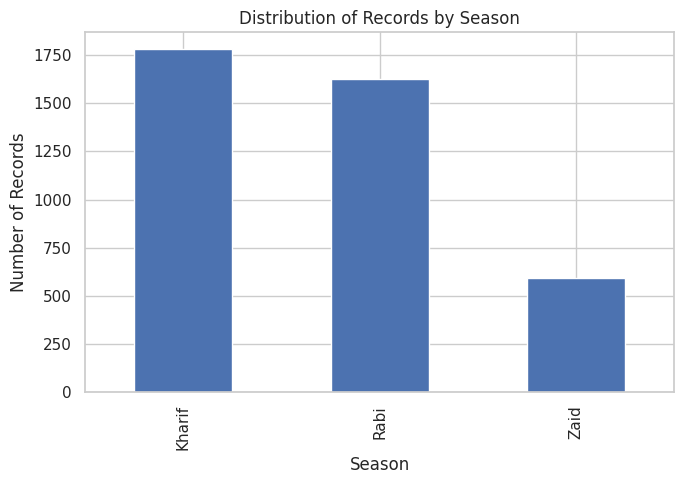

In [12]:
plt.figure(figsize=(7,5))
df["Season"].value_counts().plot.bar()
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout(); plt.show()

### Crop distribution

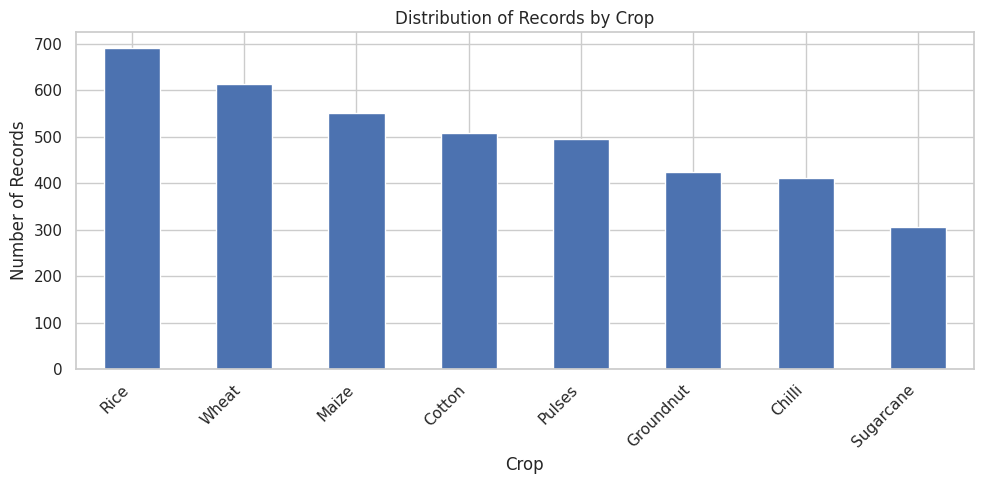

In [13]:
plt.figure(figsize=(10,5))
df["Crop"].value_counts().plot.bar()
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout(); plt.show()

### Yield distribution

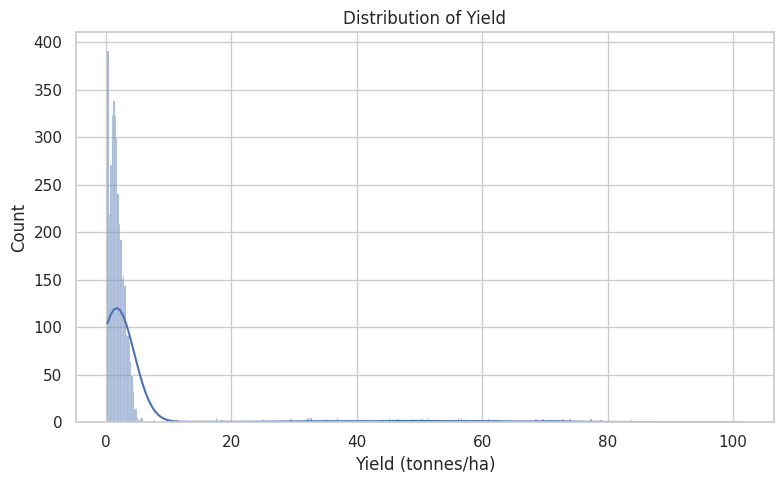

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.tight_layout(); plt.show()

### Profit distribution

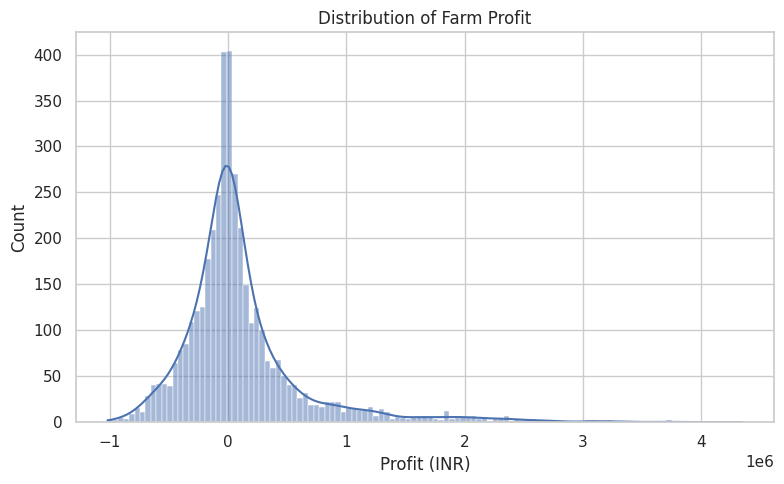

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.tight_layout(); plt.show()

### Rainfall distribution

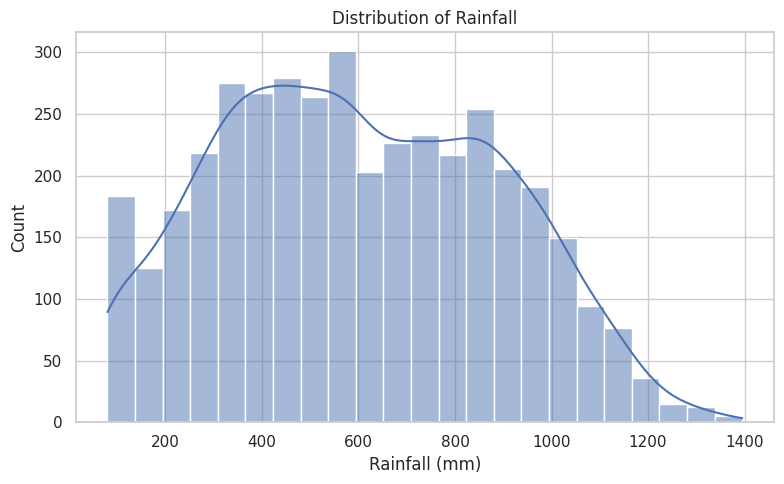

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.tight_layout(); plt.show()

### Univariate interpretation

The dataset is largest in Kharif (1,779 records), followed by Rabi (1,627) and Zaid (594). The crop distribution is spread across eight crops. Yield and profit distributions are strongly skewed, so median values and boxplots are useful complements to averages. Rainfall also varies substantially across farms, indicating diverse environmental conditions.

## 8. Outlier Analysis

In [17]:
# IQR-based outlier summary
outlier_summary = []
for col in numeric_columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, lower, upper, count, count / len(df) * 100])
outlier_summary = pd.DataFrame(outlier_summary, columns=["Column","Lower_Bound","Upper_Bound","Outlier_Count","Outlier_Percentage"]).sort_values("Outlier_Count", ascending=False)
display(outlier_summary.round(2))

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


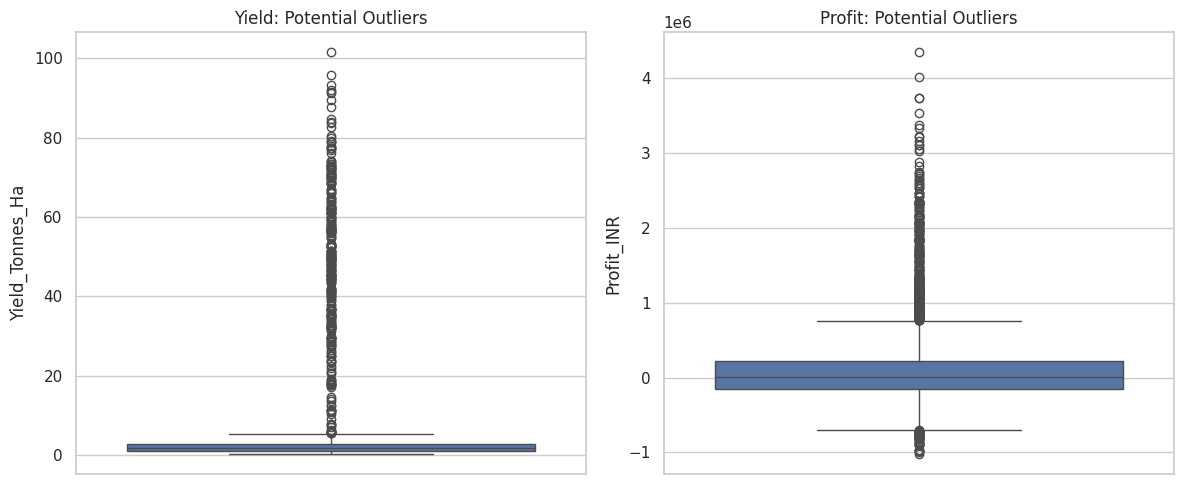

In [18]:
# Visual check for yield and profit
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha", ax=ax[0])
ax[0].set_title("Yield: Potential Outliers")
sns.boxplot(data=df, y="Profit_INR", ax=ax[1])
ax[1].set_title("Profit: Potential Outliers")
plt.tight_layout(); plt.show()

### Outlier interpretation

The IQR method identifies many extreme observations, especially in **yield, production, profit, and water efficiency**. These should not be automatically removed: the dataset contains different crops and farm scales, so genuine high-performing farms can naturally produce extreme values. The outlier results are therefore treated as a signal for further investigation rather than as automatic data errors.

## 9. Bivariate Analysis

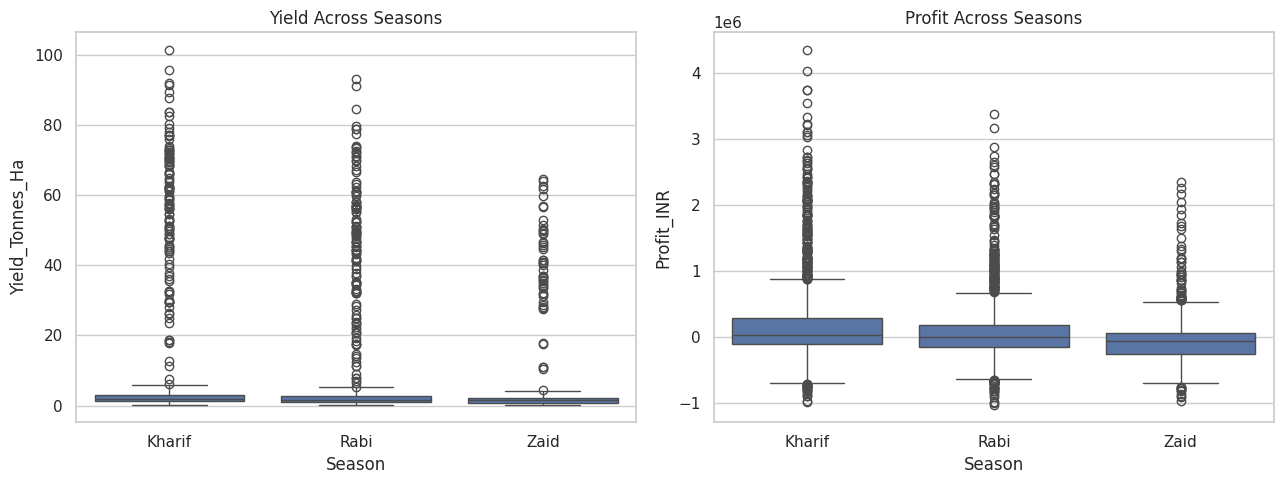

In [19]:
# Season vs yield and profit
fig, ax = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", ax=ax[0])
ax[0].set_title("Yield Across Seasons")
sns.boxplot(data=df, x="Season", y="Profit_INR", ax=ax[1])
ax[1].set_title("Profit Across Seasons")
plt.tight_layout(); plt.show()

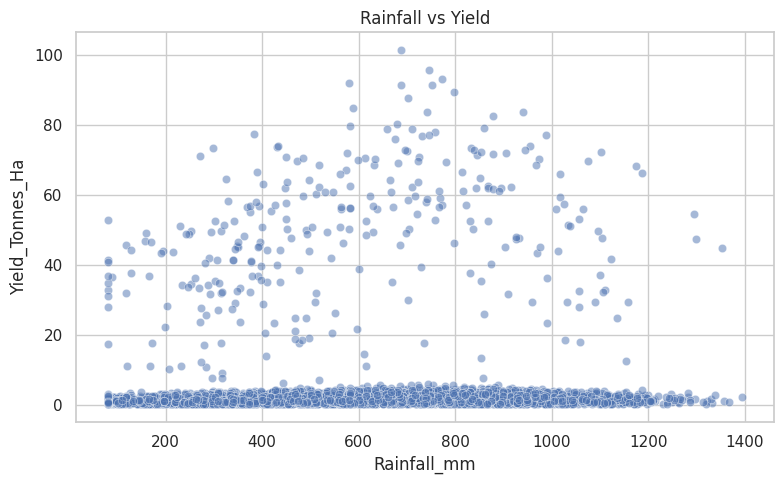

Pearson correlation: 0.031


In [20]:
# Rainfall vs yield
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Yield")
plt.tight_layout(); plt.show()
print("Pearson correlation:", round(df[["Rainfall_mm","Yield_Tonnes_Ha"]].corr().iloc[0,1], 3))

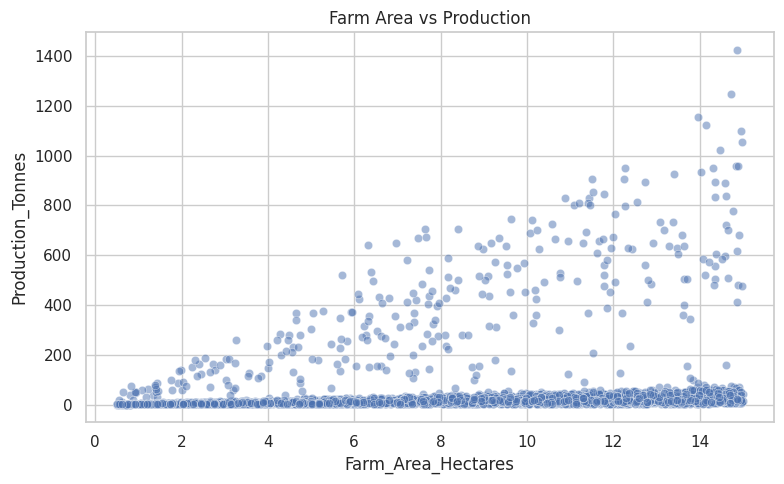

Pearson correlation: 0.198


In [21]:
# Farm area vs production
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.tight_layout(); plt.show()
print("Pearson correlation:", round(df[["Farm_Area_Hectares","Production_Tonnes"]].corr().iloc[0,1], 3))

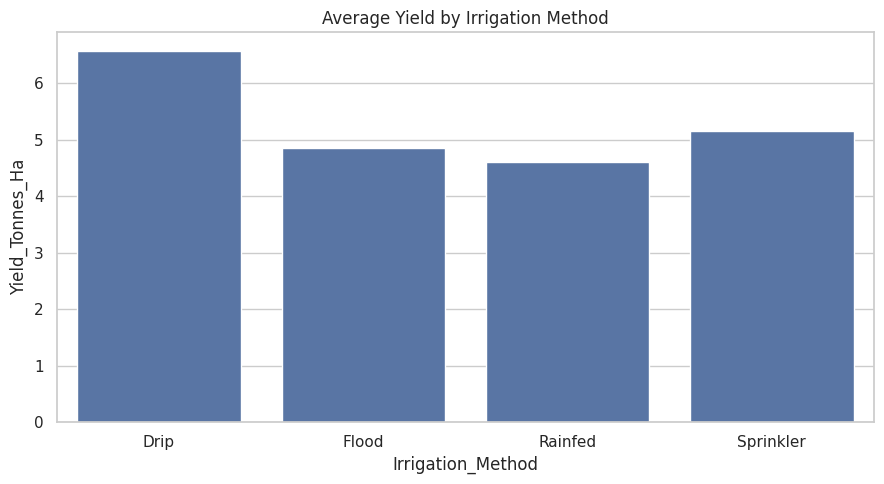

In [22]:
# Irrigation method vs yield
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield by Irrigation Method")
plt.tight_layout(); plt.show()

### Bivariate interpretation

Season is associated with clear differences in yield and profit: Kharif performs best on average and Zaid performs worst financially. Rainfall and yield have a **very weak positive correlation (0.031)**, so rainfall alone does not explain yield differences in this dataset. Farm area and production show a much stronger positive relationship because larger farms generally produce more total output. Irrigation methods also differ substantially in average yield, with Drip showing the highest average yield among the four methods.

## 10. Multivariate Analysis

In [23]:
# Crop, season and yield
crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(Average_Yield=("Yield_Tonnes_Ha", "mean"),
           Average_Profit=("Profit_INR", "mean"),
           Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"))
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)
display(crop_season_summary)

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

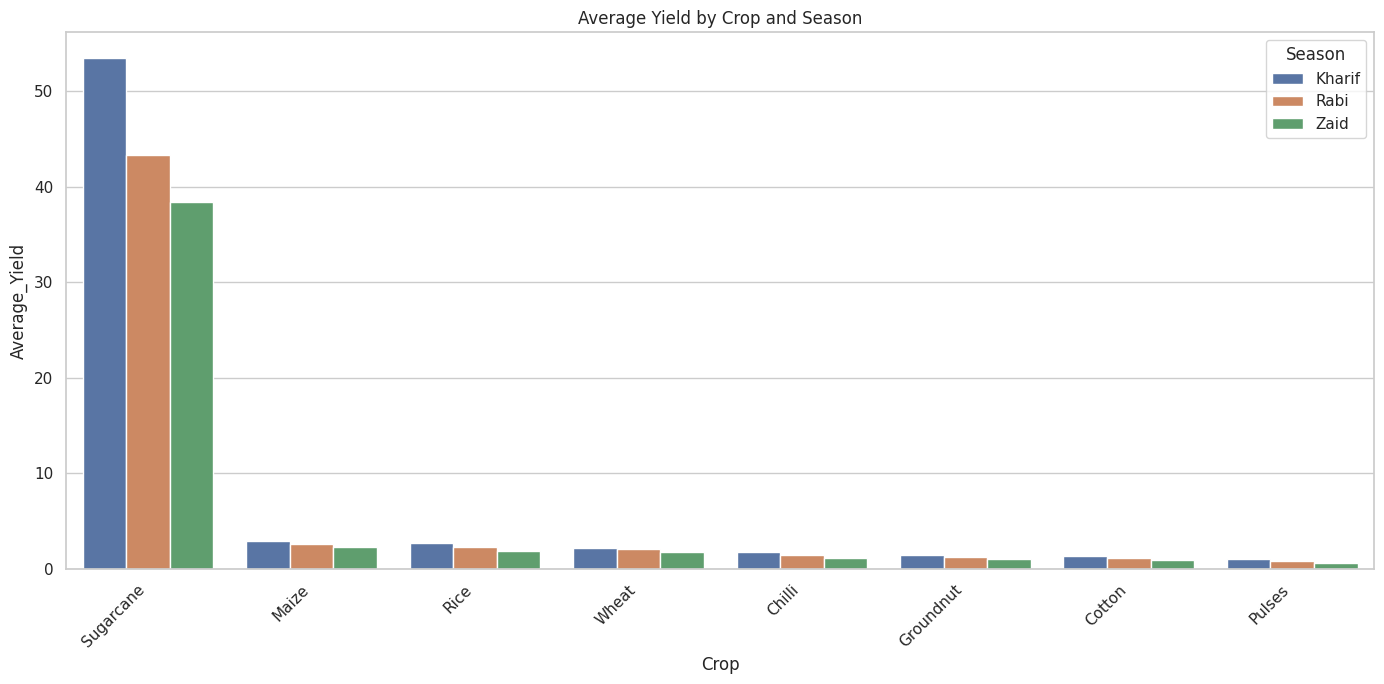

In [24]:
# Average yield by crop and season
plt.figure(figsize=(14,7))
sns.barplot(data=crop_season_summary.reset_index(), x="Crop", y="Average_Yield", hue="Season", errorbar=None)
plt.xticks(rotation=45, ha="right")
plt.title("Average Yield by Crop and Season")
plt.tight_layout(); plt.show()

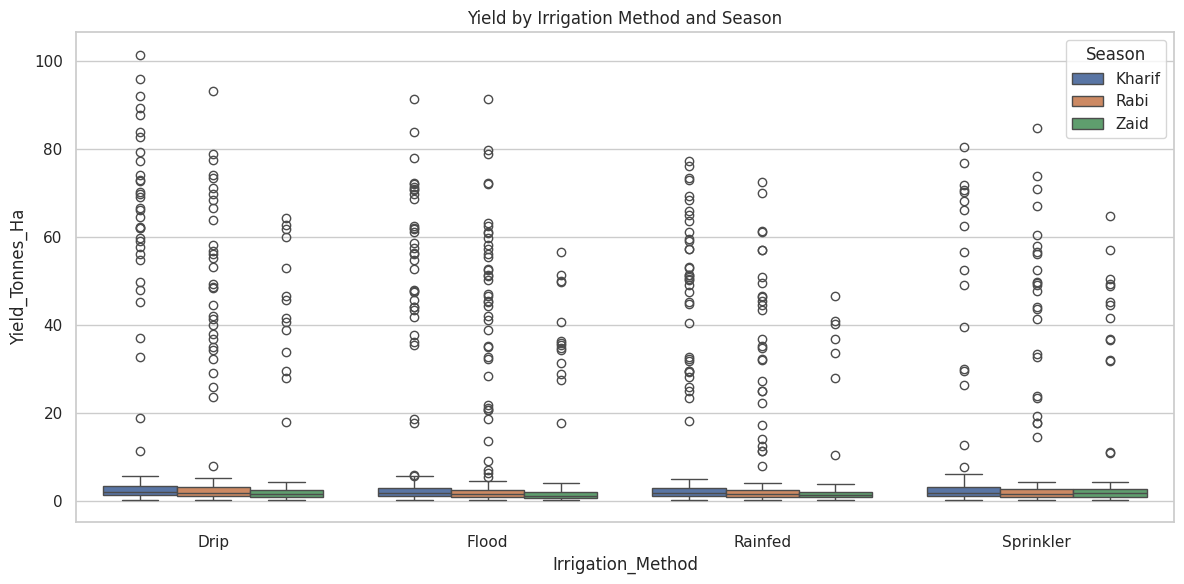

In [25]:
# Irrigation, season and yield
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.tight_layout(); plt.show()

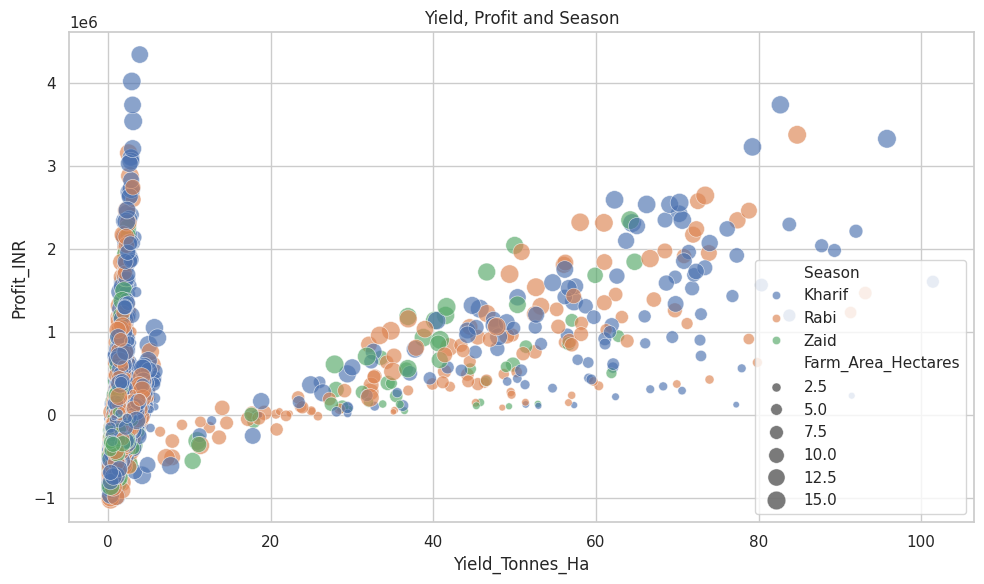

In [26]:
# Yield and profit by season
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Yield_Tonnes_Ha", y="Profit_INR", hue="Season", size="Farm_Area_Hectares", sizes=(20,180), alpha=0.65)
plt.title("Yield, Profit and Season")
plt.tight_layout(); plt.show()

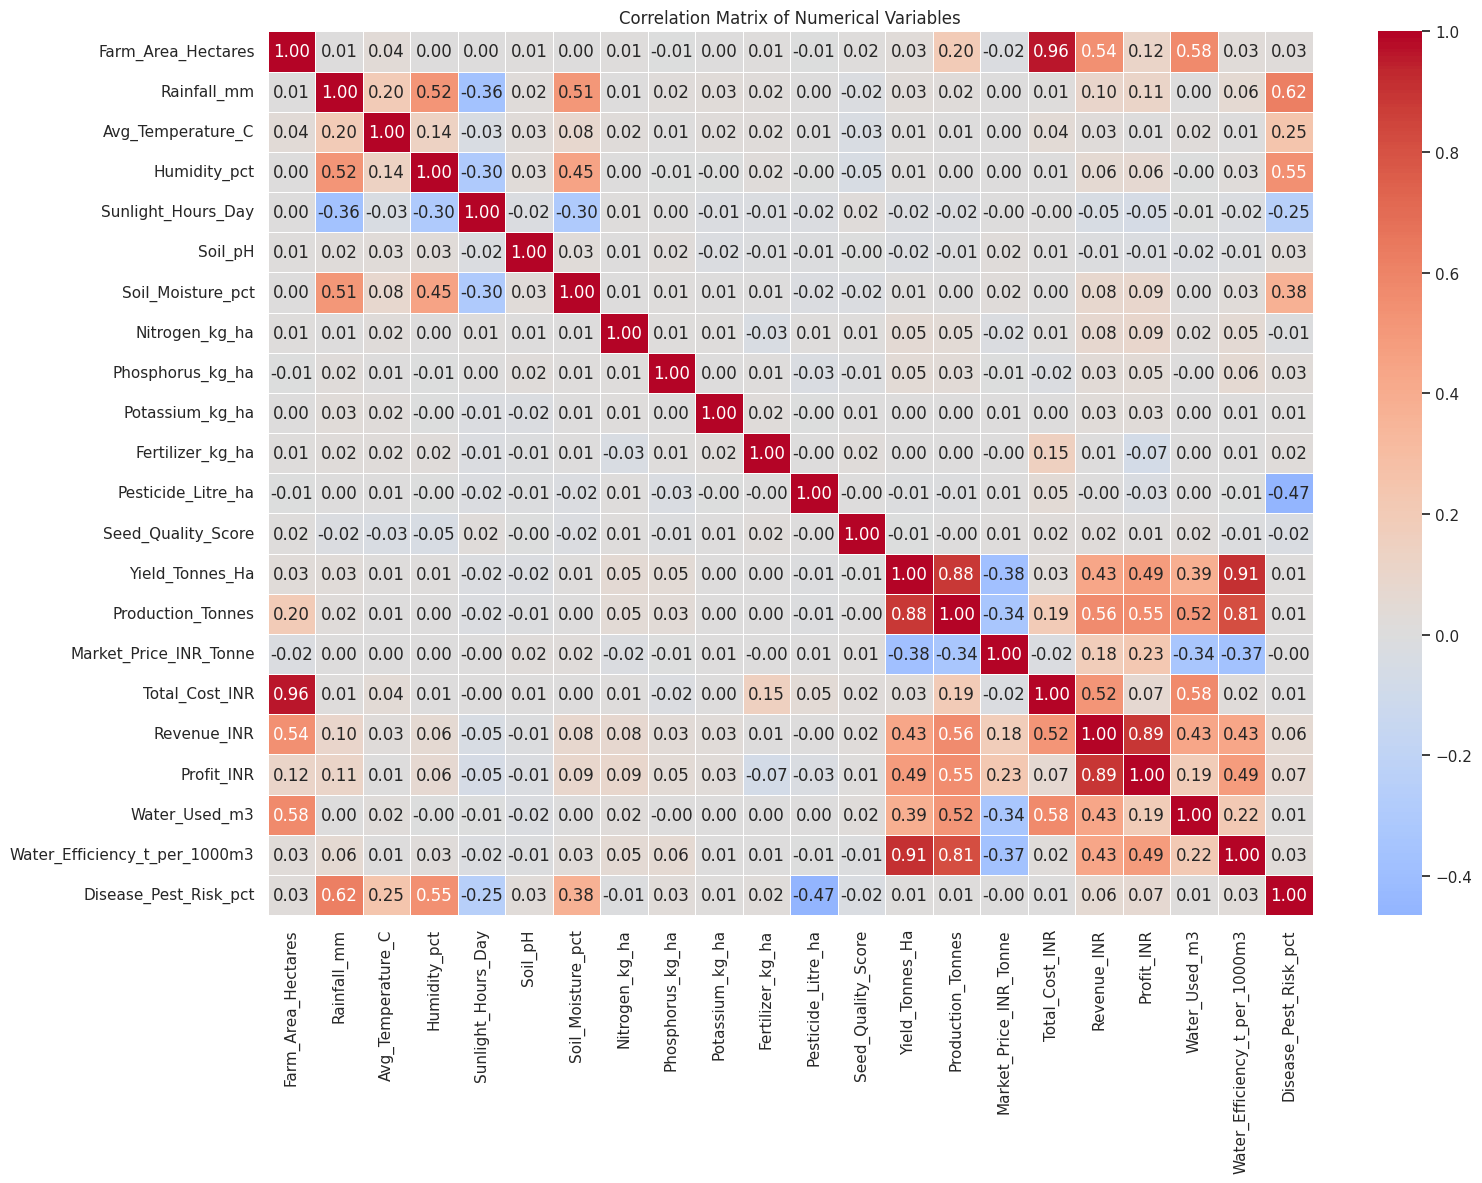

In [34]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


### Multivariate interpretation

Crop and season interact strongly: **Sugarcane has the highest average yield and profit in all three seasons**, while several other crops have much lower yields and negative average profits in some seasons. Irrigation performance also varies by season, so irrigation should not be evaluated without considering the crop and seasonal context. Yield and profit generally move together, but the relationship is affected by crop type, market price, farm scale, and costs.

## 11. Seasonal Comparison

In [28]:
# Seasonal performance summary
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)
display(season_metrics)

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Risk
Season,,,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20",5.89,54.47
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99",5.19,40.48
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89",4.41,38.22


In [29]:
# Crop performance within season
display(crop_season_summary)

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

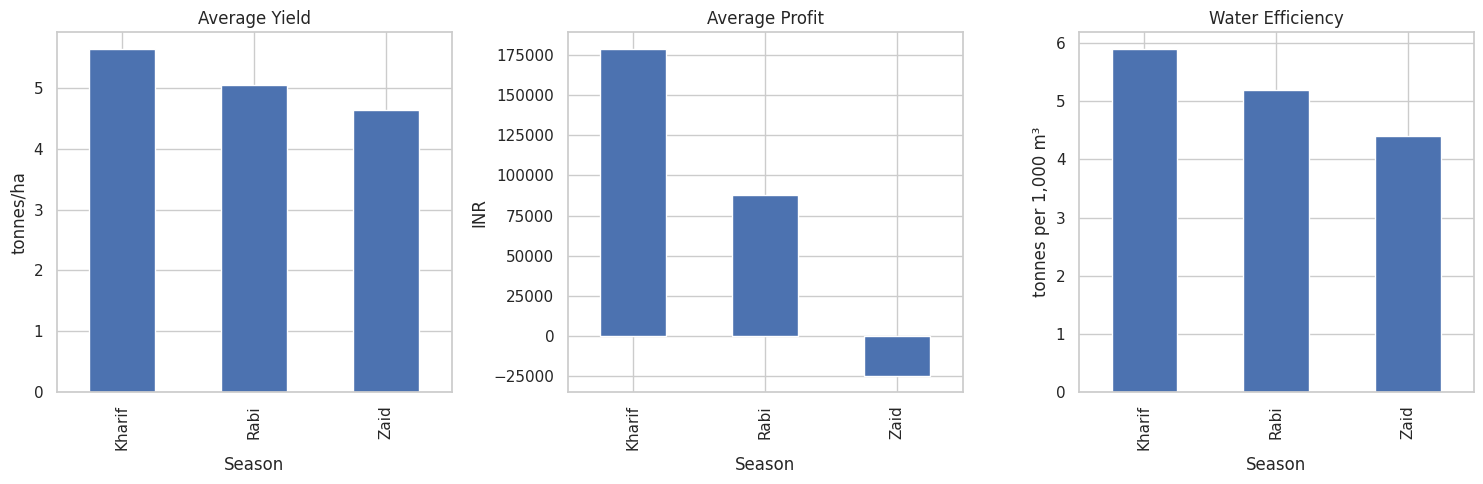

In [30]:
# Seasonal average comparison
fig, ax = plt.subplots(1, 3, figsize=(15,5))
season_metrics["Average_Yield"].plot.bar(ax=ax[0], title="Average Yield", ylabel="tonnes/ha")
season_metrics["Average_Profit"].plot.bar(ax=ax[1], title="Average Profit", ylabel="INR")
season_metrics["Average_Water_Efficiency"].plot.bar(ax=ax[2], title="Water Efficiency", ylabel="tonnes per 1,000 m³")
plt.tight_layout(); plt.show()

### Seasonal comparison findings

- **Kharif:** highest average yield (**5.64 tonnes/ha**), highest average profit (**₹178,914.65**), highest total profit (**₹318.29 million**), and highest average water efficiency (**5.89**).
- **Rabi:** second in average yield (**5.08 tonnes/ha**) and average profit (**₹87,689.47**).
- **Zaid:** lowest average yield (**4.67 tonnes/ha**) and a negative average profit (**−₹24,804.82**); its total profit is also negative.
- Kharif has the highest average disease/pest risk (**54.47%**), so its strong financial performance occurs alongside higher reported risk.
- Zaid uses the most water on average (**6,419.89 m³**) while having the lowest average water efficiency (**4.41**).

## 12. Additional Student-Driven Analysis

This section contains three additional analyses focused on farm scale and financial risk, irrigation effectiveness, and microclimatic pest risk.


/tmp/ipykernel_4462/2889074453.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scale_loss_summary = df.groupby(['Season', 'Farm_Scale']).agg(


=== Farm Scale Financial Performance & Loss Rate ===
   Season        Farm_Scale  Total_Farms  Avg_Profit  Loss_Rate_pct
0  Kharif     Small (<4 ha)          432   33,700.65          44.68
1  Kharif  Medium (4-10 ha)          671  185,481.15          38.75
2  Kharif    Large (>10 ha)          676  265,196.19          44.08
3    Rabi     Small (<4 ha)          377   23,953.31          53.85
4    Rabi  Medium (4-10 ha)          687   74,019.31          51.24
5    Rabi    Large (>10 ha)          563  147,049.92          49.20
6    Zaid     Small (<4 ha)          129   -5,764.04          59.69
7    Zaid  Medium (4-10 ha)          245  -33,087.11          64.08
8    Zaid    Large (>10 ha)          220  -26,746.20          67.73


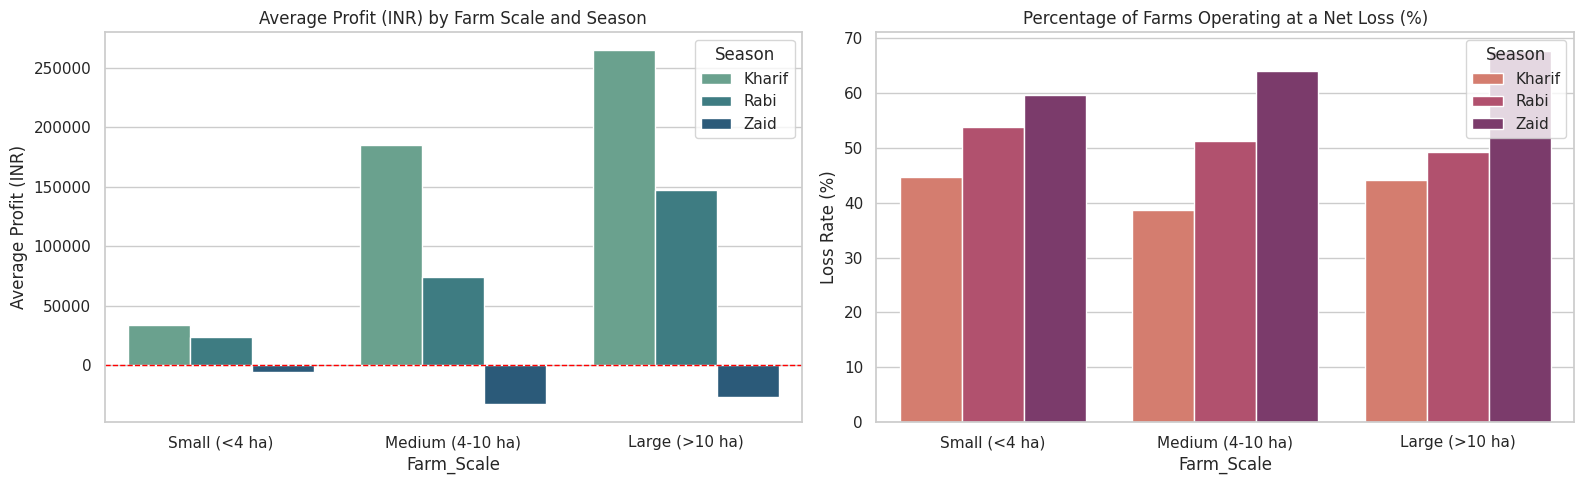

In [31]:
# Student Analysis 1: Farm Scale, Operational Expenditure & Financial Loss Rates Across Seasons
# Question: Are higher operational expenditures and larger farm sizes resulting in proportional revenue gains, or are certain farm sizes suffering systemic net losses?

# Create farm scale category
df['Farm_Scale'] = pd.cut(
    df['Farm_Area_Hectares'],
    bins=[0, 4, 10, np.inf],
    labels=['Small (<4 ha)', 'Medium (4-10 ha)', 'Large (>10 ha)']
)

scale_loss_summary = df.groupby(['Season', 'Farm_Scale']).agg(
    Total_Farms=('Farm_ID', 'count'),
    Loss_Farms=('Profit_INR', lambda x: (x < 0).sum()),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).reset_index()
scale_loss_summary['Loss_Rate_pct'] = (scale_loss_summary['Loss_Farms'] / scale_loss_summary['Total_Farms'] * 100).round(2)

print("=== Farm Scale Financial Performance & Loss Rate ===")
print(scale_loss_summary[['Season', 'Farm_Scale', 'Total_Farms', 'Avg_Profit', 'Loss_Rate_pct']])

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=scale_loss_summary, x='Farm_Scale', y='Avg_Profit', hue='Season', ax=axes[0], palette='crest')
axes[0].set_title('Average Profit (INR) by Farm Scale and Season')
axes[0].set_ylabel('Average Profit (INR)')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)

sns.barplot(data=scale_loss_summary, x='Farm_Scale', y='Loss_Rate_pct', hue='Season', ax=axes[1], palette='flare')
axes[1].set_title('Percentage of Farms Operating at a Net Loss (%)')
axes[1].set_ylabel('Loss Rate (%)')

plt.tight_layout()
plt.show()


=== Irrigation Method Effectiveness Across Seasons ===
    Season Irrigation_Method  Farms  Mean_Yield  Mean_Water_Used  \
0   Kharif              Drip    405        7.26         5,953.37   
1   Kharif             Flood    590        4.98         8,229.27   
2   Kharif           Rainfed    463        5.70         3,687.52   
3   Kharif         Sprinkler    321        4.66         5,863.27   
4     Rabi              Drip    370        6.11         5,911.41   
5     Rabi             Flood    526        5.06         7,766.83   
6     Rabi           Rainfed    438        3.93         3,298.29   
7     Rabi         Sprinkler    293        5.31         6,129.09   
8     Zaid              Drip    140        5.85         5,837.99   
9     Zaid             Flood    194        3.98         8,113.69   
10    Zaid           Rainfed    140        3.06         3,879.39   
11    Zaid         Sprinkler    120        6.14         7,324.41   

    Mean_Water_Efficiency  Mean_Profit  
0                  

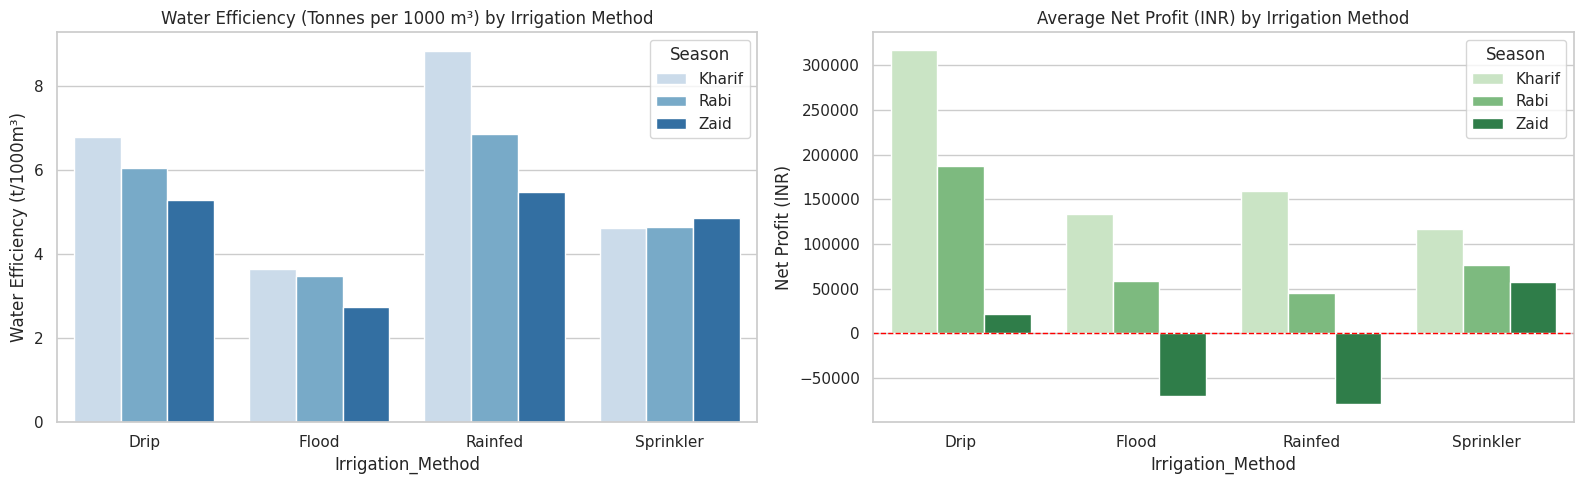

In [32]:
# Student Analysis 2: Irrigation Method Effectiveness on Yield, Water Efficiency, and Profitability
# Question: How do different irrigation methods impact water efficiency (t/1000m³) and financial returns across distinct climatic seasons?

irrig_seasonal = df.groupby(['Season', 'Irrigation_Method']).agg(
    Farms=('Farm_ID', 'count'),
    Mean_Yield=('Yield_Tonnes_Ha', 'mean'),
    Mean_Water_Used=('Water_Used_m3', 'mean'),
    Mean_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Mean_Profit=('Profit_INR', 'mean')
).round(2).reset_index()

print("=== Irrigation Method Effectiveness Across Seasons ===")
print(irrig_seasonal)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', errorbar=None, ax=axes[0], palette='Blues')
axes[0].set_title('Water Efficiency (Tonnes per 1000 m³) by Irrigation Method')
axes[0].set_ylabel('Water Efficiency (t/1000m³)')

sns.barplot(data=df, x='Irrigation_Method', y='Profit_INR', hue='Season', errorbar=None, ax=axes[1], palette='Greens')
axes[1].set_title('Average Net Profit (INR) by Irrigation Method')
axes[1].set_ylabel('Net Profit (INR)')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


=== Microclimate, Pest Risk, and Chemical Intervention ===
   Season  Mean_Humidity  Mean_Rainfall  Mean_Pesticide  Mean_Pest_Risk  \
0  Kharif          71.81         849.20            5.08           54.47   
1    Rabi          57.89         437.62            5.02           40.48   
2    Zaid          52.01         304.65            5.17           38.22   

   Mean_Yield  
0        5.63  
1        5.04  
2        4.64  


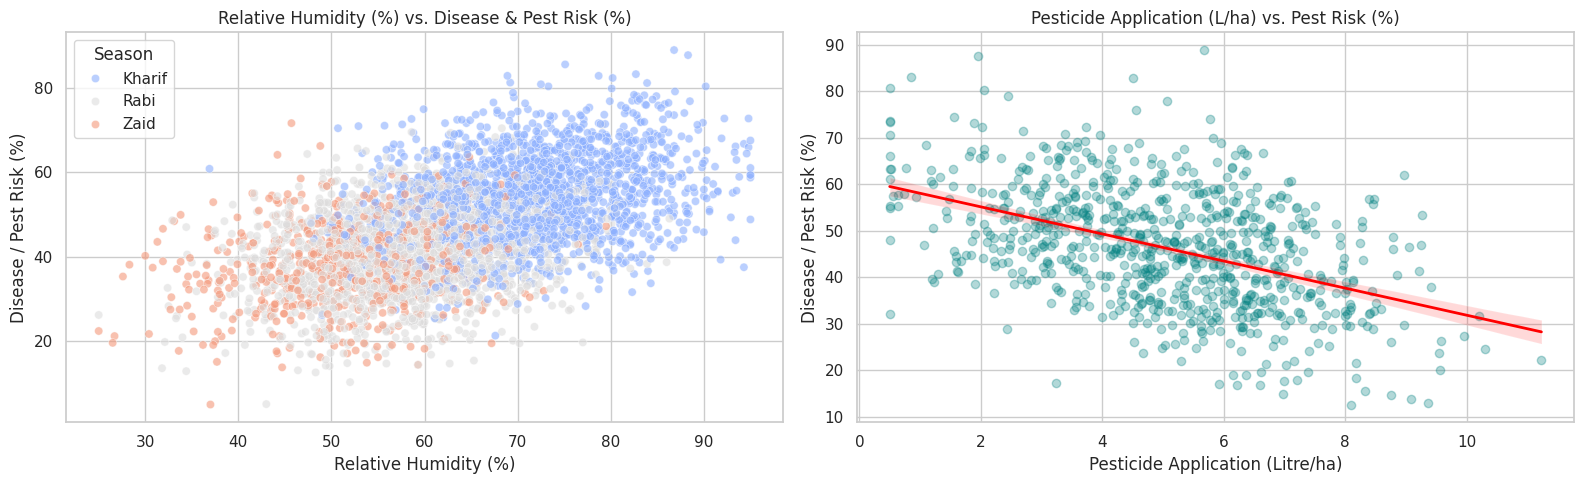

In [33]:
# Student Analysis 3: Microclimatic Humidity, Pest Risk Dynamics, and Pesticide Efficacy
# Question: What drives Disease & Pest Risk across seasons, and does chemical pesticide application effectively mitigate pest outbreaks?

pest_summary = df.groupby('Season').agg(
    Mean_Humidity=('Humidity_pct', 'mean'),
    Mean_Rainfall=('Rainfall_mm', 'mean'),
    Mean_Pesticide=('Pesticide_Litre_ha', 'mean'),
    Mean_Pest_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Mean_Yield=('Yield_Tonnes_Ha', 'mean')
).round(2).reset_index()

print("=== Microclimate, Pest Risk, and Chemical Intervention ===")
print(pest_summary)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=df,
    x='Humidity_pct',
    y='Disease_Pest_Risk_pct',
    hue='Season',
    alpha=0.6,
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title('Relative Humidity (%) vs. Disease & Pest Risk (%)')
axes[0].set_xlabel('Relative Humidity (%)')
axes[0].set_ylabel('Disease / Pest Risk (%)')

sns.regplot(
    data=df.sample(800, random_state=42),
    x='Pesticide_Litre_ha',
    y='Disease_Pest_Risk_pct',
    scatter_kws={'alpha': 0.3, 'color': 'teal'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Pesticide Application (L/ha) vs. Pest Risk (%)')
axes[1].set_xlabel('Pesticide Application (Litre/ha)')
axes[1].set_ylabel('Disease / Pest Risk (%)')

plt.tight_layout()
plt.show()


### 13. Key Insights
1. **Kharif is the strongest overall season.** It has the highest average yield (5.64 tonnes/ha), average profit (₹178,914.65), and total profit (₹318.29 million).

2. **Zaid is financially weaker.** Its average profit is −₹24,804.82 and total profit is negative, despite having a similar number of observations per farm record structure.

3. **Sugarcane dominates yield and profit across seasons.** Its average yield is 53.46 tonnes/ha in Kharif, 43.94 in Rabi, and 38.42 in Zaid, far above the other crops.

4. **Rainfall alone is not a strong predictor of yield in this dataset.** The Pearson correlation between rainfall and yield is only 0.031.

5. **Farm size is strongly related to total production.** Larger farm areas generally correspond to higher total production, so production should be interpreted separately from yield per hectare.

6. **Drip irrigation has the highest average yield.** Its average yield is 6.62 tonnes/ha, compared with 4.61 for Rainfed and 4.90 for Flood.

7. **Flood irrigation is the least water-efficient option among the listed methods.** It uses about 8,026 m³ of water on average and has an average efficiency of 3.44 tonnes per 1,000 m³.

8. **Punjab has the highest average yield and average profit among states.** Its average yield is 6.12 tonnes/ha and average profit is ₹136,025.64.

9. **Kharif also has the highest reported disease/pest risk.** Its average risk is 54.47%, compared with 40.48% in Rabi and 38.22% in Zaid.

10. **Yield and profit contain substantial outliers.** This means mean values can be strongly influenced by a smaller number of high-performing farms; median and distribution-based measures should also be considered.

**Limitation:** These findings describe associations in the available farm records. They do not prove that season, irrigation, location, rainfall, or another variable directly causes a particular outcome.

## 14. Recommendations


1. **Prioritize Kharif planning while managing its higher risk.** Kharif has the strongest average and total financial performance, but it also has the highest reported disease/pest risk.

2. **Investigate Zaid farms for profitability improvements.** Zaid combines the lowest average yield with negative average profit and relatively low water efficiency.

3. **Evaluate Drip irrigation where the objective is higher yield.** Drip has the highest average yield in the dataset and also maintains better water efficiency than Flood and Sprinkler.

4. **Reduce reliance on high-water-use Flood irrigation where practical.** Its average water use is the highest and its water efficiency is the lowest among the irrigation methods analyzed.

5. **Use crop-specific seasonal planning.** Crop performance differs substantially by season, so decisions should not rely only on overall seasonal averages.

6. **Use regional performance as a benchmark rather than a causal conclusion.** Punjab and Maharashtra show strong average profit, while Andhra Pradesh is lower; further investigation should examine crop mix, costs, prices, irrigation, and environmental conditions.

7. **Monitor outliers before making operational decisions.** Extreme values should be checked for data quality and farm-specific explanations rather than automatically removed.

## 15. Conclusion


The analysis shows clear differences in agricultural performance across seasons, crops, irrigation methods, and states. **Kharif is the strongest season overall**, with the highest average yield and profitability, while **Zaid is the weakest financially**. Sugarcane is the highest-yielding and most profitable crop in every season in this dataset.

Resource-use analysis shows that irrigation choices involve a trade-off between yield and water efficiency. Drip has the highest average yield, while Rainfed has the highest water efficiency. Flood irrigation uses the most water and has the lowest efficiency. Regional comparisons also show meaningful differences, with Punjab leading the states on average yield and profit.

The dataset contains substantial variation and outliers, so averages should be interpreted together with medians and distributions. The analysis identifies associations rather than causal effects. Further work could use statistical testing or predictive models to control for crop, farm size, location, environmental conditions, and market factors.